In [39]:
import numpy as np
from Functions_Binned_Analysis import Exclusion_Limit, CAST, IAXO, IAXOplus, L_ES
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

CL = 0.95 # exclusion limits @95% CL
b_CAST = 0.75 # background of CAST
b_IAXO = 0.0 # expected background of IAXO
b_IAXOplus = 0.0 # expected background of IAXO+
mixing = np.pi/4.0
L_source = L_ES
w_min = 0.0 # [keV]
w_max = 20.0 # [keV]
N_bins = 200
res_on = True
w_res = 100e-3 # [keV]

dm2_1 = np.logspace(-18,-16,3)
dm2_2 = np.logspace(-16,-12,100)
dm2_3 = np.logspace(-12,-6,3)
dm2_4 = np.logspace(-6,0,100)
delta_m21_sq_vals = np.unique(np.concatenate([dm2_1,dm2_2,dm2_3,dm2_4]))
x = np.sqrt(delta_m21_sq_vals) # [eV]
g_excl_CAST = np.empty_like(delta_m21_sq_vals,dtype=float)
g_excl_IAXO = np.empty_like(delta_m21_sq_vals,dtype=float)
g_excl_IAXOplus = np.empty_like(delta_m21_sq_vals,dtype=float)
    
for k,dm2 in enumerate(delta_m21_sq_vals):
    g_excl_CAST[k] = Exclusion_Limit(CL,b_CAST,(1+1e-10)*np.sqrt(dm2),dm2,
                                     mixing,CAST["B"],CAST["L"],L_source,CAST["S"],CAST["t"],CAST["eps_T"],CAST["eps_D"],
                                     w_min,w_max,N_bins,
                                     res_on=res_on,w_res=w_res)
    
    g_excl_IAXO[k] = Exclusion_Limit(CL,b_IAXO,(1+1e-10)*np.sqrt(dm2),dm2,
                                     mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],
                                     w_min,w_max,N_bins,
                                     res_on=res_on,w_res=w_res)

    g_excl_IAXOplus[k] = Exclusion_Limit(CL,b_IAXOplus,(1+1e-10)*np.sqrt(dm2),dm2,
                                         mixing,IAXOplus["B"],IAXOplus["L"],L_source,IAXOplus["S"],IAXOplus["t"],IAXOplus["eps_T"],IAXOplus["eps_D"],
                                         w_min,w_max,N_bins,
                                         res_on=res_on,w_res=w_res)

np.savetxt("input_data/CAST_exclusion.dat",
           np.column_stack((x,g_excl_CAST)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_CAST [GeV^-1]    (varphi = pi/4, w_res = 100 eV)")

np.savetxt("input_data/IAXO_projection.dat",
           np.column_stack((x,g_excl_IAXO)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXO [GeV^-1]    (varphi = pi/4, w_res = 100 eV)")

np.savetxt("input_data/IAXOplus_projection.dat",
           np.column_stack((x,g_excl_IAXOplus)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXOplus [GeV^-1]    (varphi = pi/4, w_res = 100 eV)")


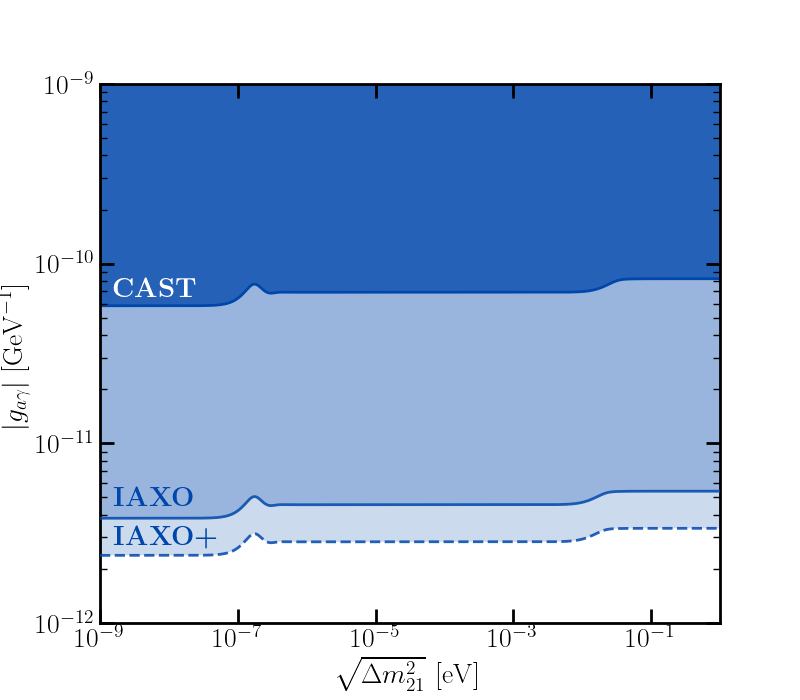

In [2]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

plt.rcParams.update({
   "text.usetex":True,
   "font.size":20,
   "axes.formatter.limits":[-3,3],
   "axes.linewidth":2,
   "lines.linewidth":2,
   "xtick.top":True,
   "xtick.bottom":True,
   "ytick.left":True,
   "ytick.right":True,
   "xtick.minor.visible":True,
   "ytick.minor.visible":True,
   "xtick.direction":"in",
   "ytick.direction":"in",
   "xtick.major.width":2,
   "xtick.minor.width":1,
   "ytick.major.width":2,
   "ytick.minor.width":1,
   "xtick.major.size":10,
   "xtick.minor.size":5,
   "ytick.major.size":10,
   "ytick.minor.size":5,
   "figure.figsize":[8,7],
   "savefig.dpi":300,
   "savefig.transparent":True
})

gs = gridspec.GridSpec(1,1,wspace=0.0)
fig = plt.figure()
ax = fig.add_subplot(gs[0])
ax.set_xlim(left=1e-9,right=1e0)
ax.set_ylim(bottom=1e-12,top=1e-9)
plt.xlabel(r"$\sqrt{\Delta m_{21}^2}\ [\mathrm{eV}]$")
plt.ylabel(r"$|g_{a\gamma}|\ [\mathrm{GeV}^{-1}]$")

folder = "input_data"

# Exclusion limit CAST @95 CL
CAST = np.loadtxt(os.path.join(folder,"CAST_exclusion.dat"))
x_CAST = CAST[:,0]
g_excl_CAST = CAST[:,1]
plt.loglog(x_CAST,g_excl_CAST,color="#0047AB",zorder=1)
ax.fill_between(x_CAST,g_excl_CAST,ax.get_ylim()[1],facecolor="#0047AB",zorder=0.5,alpha=0.85)
ax.text(1.56e-9,6.5e-11,r'{\bf CAST}',fontsize=20,color='w',zorder=1000)

# Exclusion limit IAXO @95 CL
IAXO = np.loadtxt(os.path.join(folder,"IAXO_projection.dat"))
x_IAXO = IAXO[:,0]
g_excl_IAXO = IAXO[:,1]
plt.loglog(x_IAXO,g_excl_IAXO,color="#0047AB",zorder=8,alpha=0.85)
ax.fill_between(x_IAXO,g_excl_IAXO,g_excl_CAST,facecolor="#0047AB",zorder=0.05,alpha=0.4)
ax.text(1.56e-9,4.5e-12,r'{\bf IAXO}',fontsize=20,color="#0047AB",zorder=1000)

# Exclusion limit IAXOplus @95 CL
IAXOplus = np.loadtxt(os.path.join(folder,"IAXOplus_projection.dat"))
x_IAXOplus = IAXOplus[:,0]
g_excl_IAXOplus = IAXOplus[:,1]
plt.loglog(x_IAXOplus,g_excl_IAXOplus,color="#0047AB",ls='--',zorder=8,alpha=0.85)
ax.fill_between(x_IAXOplus,g_excl_IAXOplus,g_excl_IAXO,facecolor="#0047AB",zorder=0.05,alpha=0.2)
ax.text(1.56e-9,2.7e-12,r'{\bf IAXO+}',fontsize=20,color="#0047AB",zorder=1000)

plt.show()